<a href="https://colab.research.google.com/github/Ven0mite/Homework3_Nelan_Remy/blob/main/Homework3_RN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [69]:
# Homework Assignment 3: Data Analysis & Optimization

# Remy Nelan



import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import minimize, curve_fit
import matplotlib.pyplot as plt

In [36]:
# Part 1 Stream Water Quality Analysis

# A.1
from io import StringIO

water_quality_csv = """site_id,date,temp_c,do_mg_l,ph,conductivity_us
SITE_A,2024-05-15,12.3,9.2,7.1,245
SITE_A,2024-05-22,14.1,8.5,7.3,252
SITE_A,2024-06-05,16.8,7.2,7.0,268
SITE_A,2024-06-19,19.2,5.8,6.8,285
SITE_A,2024-07-03,22.5,4.5,6.9,312
SITE_A,2024-07-17,24.1,3.8,7.1,298
SITE_A,2024-08-01,23.8,4.2,7.2,305
SITE_A,2024-08-15,21.2,5.5,7.0,289
SITE_B,2024-05-15,11.8,10.1,7.4,198
SITE_B,2024-05-22,13.5,9.8,7.5,205
SITE_B,2024-06-05,15.9,8.9,7.3,215
SITE_B,2024-06-19,18.4,7.5,7.2,228
SITE_B,2024-07-03,21.2,6.2,7.1,245
SITE_B,2024-07-17,22.8,5.8,7.0,251
SITE_B,2024-08-01,22.1,6.1,7.1,248
SITE_B,2024-08-15,20.5,7.0,7.2,235
SITE_C,2024-05-15,13.1,8.8,6.2,312
SITE_C,2024-05-22,14.8,8.1,6.4,325
SITE_C,2024-06-05,17.2,6.5,6.3,348
SITE_C,2024-06-19,20.1,5.2,6.1,372
SITE_C,2024-07-03,23.4,3.5,6.0,398
SITE_C,2024-07-17,25.2,2.8,5.9,412
SITE_C,2024-08-01,24.5,3.2,6.1,405
SITE_C,2024-08-15,22.3,4.1,6.2,385"""

df = pd. read_csv(StringIO(water_quality_csv))

df.head()

# A.2
df.shape

df.dtypes

# A.3
df.isna().sum()

# A.4
df["date"] = pd.to_datetime(df["date"])
df.dtypes

# Part 1.B: Data analysis with grouping

# B.1
oxy_stats = df.groupby("site_id")["do_mg_l"].agg(["mean", "std", "min", "max"])
oxy_stats

# B.2
oxy_stats["mean"].idxmin()

# B.3
def classify_oxy(do):
  if do < 4:
    return "Critical"
  elif do < 6:
    return "Low"
  elif do < 8:
    return "Adequate"
  else:
    return "Good"

df["do_status"] = df["do_mg_l"].apply(classify_oxy)
df.head()

# B.4
oxy_counts = df.groupby(["site_id", "do_status"]).size().unstack(fill_value=0)
oxy_counts

# Part 1.C: Filtering and summary

# C.1
filtered = df[
    (df["temp_c"] > 15) &
    (df["ph"] >= 6.5) &
    (df["ph"] <= 8.5)
].copy()

filtered.head()

# C.2
filtered["month"] = filtered["date"].dt.month

conductivity = (
    filtered
    .groupby("month")["conductivity_us"]
    .mean()
)

conductivity

# C.3
outliers = filtered[
    filtered["do_status"].isin(["Critical", "Low"])
]
site_month = (
    outliers
    .groupby(["site_id", "month"])
    .size()
)

site_month.idxmax()

('SITE_A', np.int32(7))

In [49]:
# Part 2 Statistical Comparison of Forest Plots

# A.1

# Forest plot data
np.random.seed(458)  # For reproducibility

# Control plots: untreated forest
n_control = 35
dbh_control = np.random.uniform(15, 50, n_control)
biomass_control = 0.1 * dbh_control**2.2 + np.random.normal(0, 15, n_control)
biomass_control = np.maximum(biomass_control, 10)  # Ensure positive

# Thinned plots: trees have more resources, potentially larger
n_thinned = 30
dbh_thinned = np.random.uniform(18, 55, n_thinned)
biomass_thinned = 0.12 * dbh_thinned**2.2 + np.random.normal(5, 18, n_thinned)
biomass_thinned = np.maximum(biomass_thinned, 10)

# Create DataFrame
forest_df = pd.DataFrame({
    'dbh_cm': np.concatenate([dbh_control, dbh_thinned]),
    'biomass_kg': np.concatenate([biomass_control, biomass_thinned]),
    'treatment': ['Control']*n_control + ['Thinned']*n_thinned
})

forest_df.head()

group_stats = forest_df.groupby('treatment')['biomass_kg'].agg(['mean', 'std', 'median'])

print(group_stats)

# A.2

control = forest_df[forest_df['treatment'] == 'Control']['biomass_kg']
thinned = forest_df[forest_df['treatment'] == 'Thinned']['biomass_kg']

t_stat, p_value = stats.ttest_ind(control, thinned)

print(t_stat)
print(p_value)

# A.3

alpha = 0.05

print("H0: Mean biomass (Control) = Mean biomass (Thinned)")
print("H1: Mean biomass (Control =/ Mean biomass (Thinned)")

if p_value < alpha:
  print("Reject H0")
else:
  print("Do not reject H0")

# B.1

r, p_corr = stats.pearsonr(forest_df['dbh_cm'], forest_df['biomass_kg'])

print(r)
print(p_corr)

# B.2

if p_corr < alpha:
  print("Correlation is statistically significant")
else:
  print("Correlation is not statistically significant")

# B.3

if r> 0:
  print("Positive correlation: As DBH increased, biomass increased")
else:
  print("Negative correlation: As DBH increased, biomass decreased")

print("Strength:", abs(r))

# C.1

mu, sigma = stats.norm.fit(control)

print(mu)
print(sigma)

# C.2

param = 1 - stats.norm.cdf(150, mu, sigma)

print(param)

# C.3

percent90 = stats.norm.ppf(0.90, mu, sigma)

print(percent90)

                 mean         std      median
treatment                                    
Control    269.642640  158.210017  232.870089
Thinned    325.418953  213.516434  239.121336
-1.2070240725368289
0.23193539340140698
H0: Mean biomass (Control) = Mean biomass (Thinned)
H1: Mean biomass (Control =/ Mean biomass (Thinned)
Do not reject H0
0.9564725425194496
2.0975940245401606e-35
Correlation is statistically significant
Positive correlation: As DBH increased, biomass increased
Strength: 0.9564725425194496
269.64263954151227
155.93349560108524
0.7785386347064978
469.47945494992507


PAR range: 0 to 1800 μmol photons m⁻² s⁻¹
Photosynthesis range: -1.8 to 23.1 μmol CO₂ m⁻² s⁻¹
15.857142857142858
28.44605494901702
134.75452985437354
2.6271705321314256
0.23733661466729108


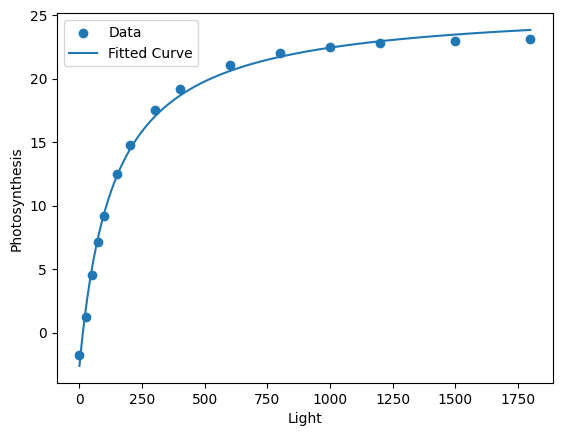

0.996574978815181
13.711790338745345
25.818884416885595


In [67]:
# Part 3 Fitting a Light Response Curve

# A.1

# Light response curve data
# PAR (photosynthetically active radiation) in μmol photons m⁻² s⁻¹
par_data = np.array([0, 25, 50, 75, 100, 150, 200, 300, 400, 600, 800, 1000, 1200, 1500, 1800])

# Net photosynthesis rate in μmol CO₂ m⁻² s⁻¹
photo_data = np.array([-1.8, 1.2, 4.5, 7.1, 9.2, 12.5, 14.8, 17.5, 19.2, 21.1, 22.0, 22.5, 22.8, 23.0, 23.1])

print(f"PAR range: {par_data.min()} to {par_data.max()} μmol photons m⁻² s⁻¹")
print(f"Photosynthesis range: {photo_data.min()} to {photo_data.max()} μmol CO₂ m⁻² s⁻¹")

def light_response(I, Amax, K, Rd):
  """
  I = light intensity
  Amax = maximum photosynthesis rate
  K = half-saturation constant
  Rd = dark respiration rate
  """
  return (Amax * I) / (K + I) - Rd

# A.2
def light_response_mse(params, I_data, A_data):
  Amax, K, Rd = params
  predictions = light_response(I_data, Amax, K, Rd)
  mse = np.mean((A_data - predictions) ** 2)
  return mse

# A.3
test_val = light_response(500, 25, 200, 2)
print(test_val)

# B.1/2/3

initial_guess = [20, 150, 1]

result = minimize(light_response_mse,
                  initial_guess,
                  args=(par_data, photo_data))

Amax_fit, K_fit, Rd_fit = result.x
final_mse = result.fun

print(Amax_fit)
print(K_fit)
print(Rd_fit)
print(final_mse)

# B.4

I_smooth = np.linspace(0, 1800, 300)
A_smooth = light_response(I_smooth, Amax_fit, K_fit, Rd_fit)

plt.scatter(par_data, photo_data, label="Data")
plt.plot(I_smooth, A_smooth, label="Fitted Curve")
plt.xlabel("Light")
plt.ylabel("Photosynthesis")
plt.legend()
plt.show()

# C.1/2
predicted = light_response(par_data, Amax_fit, K_fit, Rd_fit)

SSres = np.sum((photo_data - predicted) ** 2)
SStot = np.sum((photo_data - np.mean(photo_data)) ** 2)

R2 = 1 - (SSres / SStot)

print(R2)

# C.3
I_comp = (Rd_fit * K_fit) / (Amax_fit - Rd_fit)

print(I_comp)
print(Amax_fit - Rd_fit)